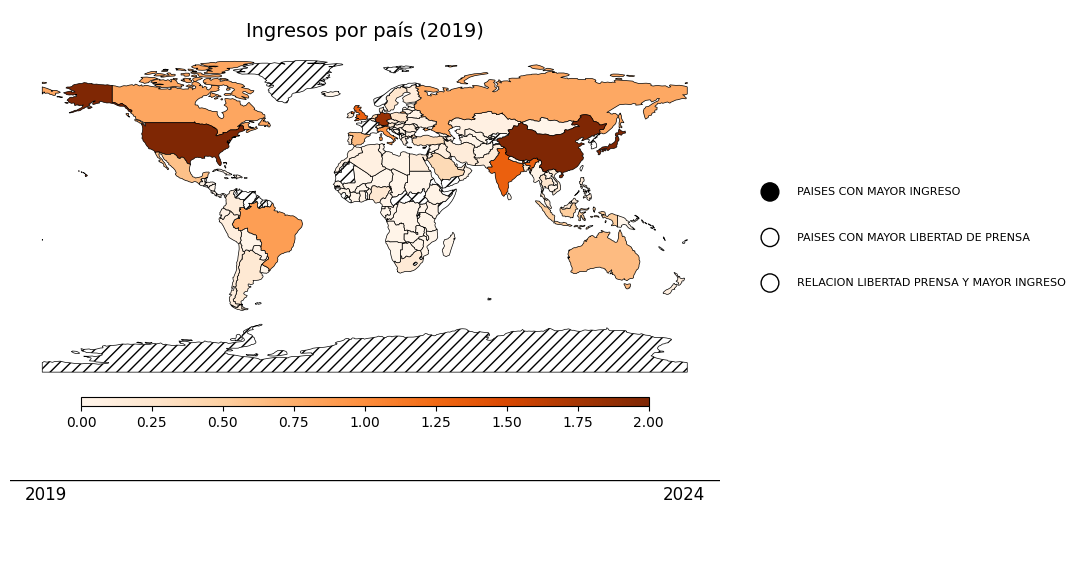

In [77]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

world = gpd.read_file("ne_data/ne_110m_admin_0_countries.shp")
df_income = pd.read_csv("data limpia\\Countries_GDP_2019.csv")

income = df_income[['2019_country_code', '2019_porcentaje']].rename(columns={
    '2019_country_code': 'ISO_A3',
    '2019_porcentaje': 'income_2019'
})

income['income_2019'] = income['income_2019'].replace(0, np.nan)

world_income = world.merge(income, on='ISO_A3', how='left')

fig = plt.figure(figsize=(11, 6))
grid_color = '#E6E6E6'
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(2, 2, height_ratios=[6, 1], width_ratios=[4, 1])

ax_map = fig.add_subplot(gs[0, 0])
world_income.plot(
    column='income_2019',
    cmap='Oranges',
    linewidth=0.5,
    ax=ax_map,
    edgecolor='black',
    legend=True,
    vmin=0,
    vmax=2,
    legend_kwds={
        'orientation': "horizontal",
        'shrink': 0.8,  # 👈 achica la barra
        'aspect': 60,   # 👈 más alargada y baja
        'pad': 0.02     # 👈 separa un poco del mapa
    },
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sin datos"
    }
)


ax_map.set_title('Ingresos por país (2019)', fontsize=14)
ax_map.axis('off')

ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['2', '4', '6', '8', '10']
# Add the missing label for the first tick
labels = ['0'] + labels  # Now we have 6 labels for 6 ticks
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)

ax_timeline = fig.add_subplot(gs[1, 0])
ax_timeline.axhline(y=1, color='black', linestyle='-', linewidth=1)
ax_timeline.text(0.05, 0.8, '2019', fontsize=12, ha='center', va='center')
ax_timeline.text(0.95, 0.8, '2024', fontsize=12, ha='center', va='center')
ax_timeline.set_xlim(0, 1)
ax_timeline.set_ylim(0, 1)
ax_timeline.axis('off')

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')

# Create custom legend with circles
legend_y_positions = [0.6, 0.5, 0.4]
legend_labels = ['PAISES CON MAYOR INGRESO', 'PAISES CON MAYOR LIBERTAD DE PRENSA', 
                'RELACION LIBERTAD PRENSA Y MAYOR INGRESO']

# Add circles for the legend
oval_colors = ['black', 'white', 'white']
for i, (y, label, color) in enumerate(zip(legend_y_positions, legend_labels, oval_colors)):
    # Usar Ellipse con width=0.1 y height=0.04 para crear óvalos más alargados
    oval = Ellipse((0.2, y), width=0.1, height=0.04, facecolor=color, edgecolor='black')
    ax_legend.add_patch(oval)
    # Ajustar la posición del texto para que esté bien alineado con los óvalos
    ax_legend.text(0.35, y, label, va='center', fontsize=8)

plt.tight_layout()
plt.show()

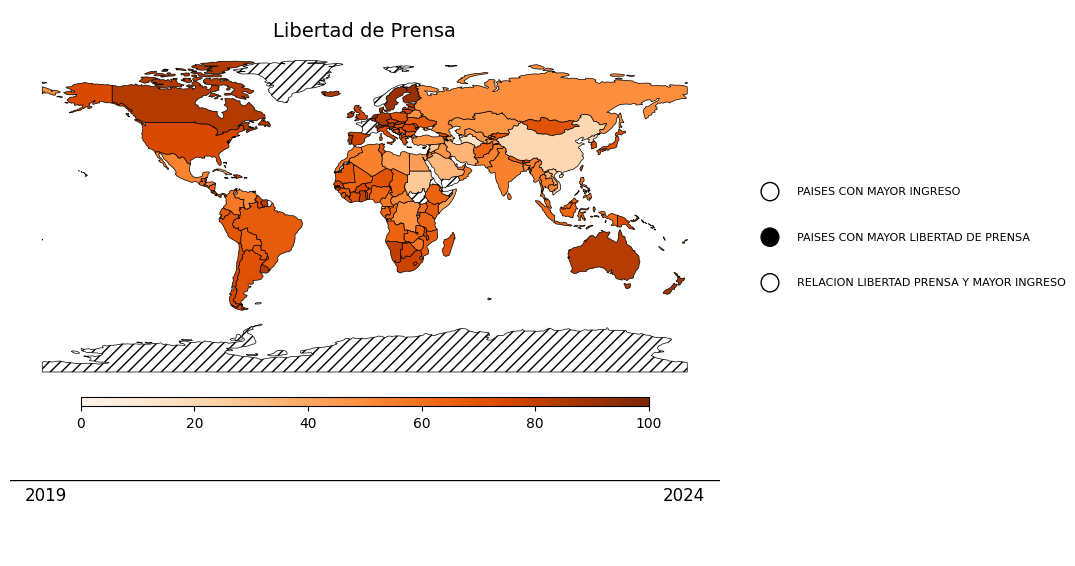

In [78]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

world = gpd.read_file("ne_data/ne_110m_admin_0_countries.shp")
df_press = pd.read_csv("Prensa_Ingreso.csv")

press = df_press[['2019_country_code', '2019_Score']].rename(columns={
    '2019_country_code': 'ISO_A3',
    '2019_Score': 'score_2019'
})

press['score_2019'] = press['score_2019'].replace(0, np.nan)

world_press = world.merge(press, on='ISO_A3', how='left')

fig = plt.figure(figsize=(11, 6))
grid_color = '#E6E6E6'
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(2, 2, height_ratios=[6, 1], width_ratios=[4, 1])

ax_map = fig.add_subplot(gs[0, 0])
world_press.plot(
    column='score_2019',
    cmap='Oranges',
    linewidth=0.5,
    ax=ax_map,
    edgecolor='black',
    legend=True,
    vmin=0,
    vmax=100,
    legend_kwds={
        'orientation': "horizontal",
        'shrink': 0.8,  # 👈 achica la barra
        'aspect': 60,   # 👈 más alargada y baja
        'pad': 0.02     # 👈 separa un poco del mapa
    },
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sin datos"
    }
)


ax_map.set_title('Libertad de Prensa', fontsize=14)
ax_map.axis('off')

ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['2', '4', '6', '8', '10']
# Add the missing label for the first tick
labels = ['0'] + labels  # Now we have 6 labels for 6 ticks
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)

ax_timeline = fig.add_subplot(gs[1, 0])
ax_timeline.axhline(y=1, color='black', linestyle='-', linewidth=1)
ax_timeline.text(0.05, 0.8, '2019', fontsize=12, ha='center', va='center')
ax_timeline.text(0.95, 0.8, '2024', fontsize=12, ha='center', va='center')
ax_timeline.set_xlim(0, 1)
ax_timeline.set_ylim(0, 1)
ax_timeline.axis('off')

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')

# Create custom legend with circles
legend_y_positions = [0.6, 0.5, 0.4]
legend_labels = ['PAISES CON MAYOR INGRESO', 'PAISES CON MAYOR LIBERTAD DE PRENSA', 
                'RELACION LIBERTAD PRENSA Y MAYOR INGRESO']

# Add circles for the legend
oval_colors = ['white', 'black', 'white']
for i, (y, label, color) in enumerate(zip(legend_y_positions, legend_labels, oval_colors)):
    # Usar Ellipse con width=0.1 y height=0.04 para crear óvalos más alargados
    oval = Ellipse((0.2, y), width=0.1, height=0.04, facecolor=color, edgecolor='black')
    ax_legend.add_patch(oval)
    # Ajustar la posición del texto para que esté bien alineado con los óvalos
    ax_legend.text(0.35, y, label, va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [83]:
import pandas as pd
import numpy as np

# Cargar el archivo
df = pd.read_csv("Prensa_Ingreso.csv")

# Tomamos solo las columnas que necesitamos
df = df[['2020_country_code', '2020_porcentaje', '2020_Score']].copy()

# Normalizar ingreso (de 0 a 1, más ingreso = mejor)
df['ingreso_norm'] = (df['2020_porcentaje'] - df['2020_porcentaje'].min()) / (df['2020_porcentaje'].max() - df['2020_porcentaje'].min())

# Normalizar score de prensa (más bajo = mejor, así que lo invertimos)
df['prensa_norm'] = 1 - (df['2020_Score'] - df['2020_Score'].min()) / (df['2020_Score'].max() - df['2020_Score'].min())

# Puedes simplemente promediar ambos valores
df['indice_combinado'] = (df['ingreso_norm'] + df['prensa_norm']) / 2

# guardalo en un csv propio
df.to_csv("indice_combinado.csv", index=False)

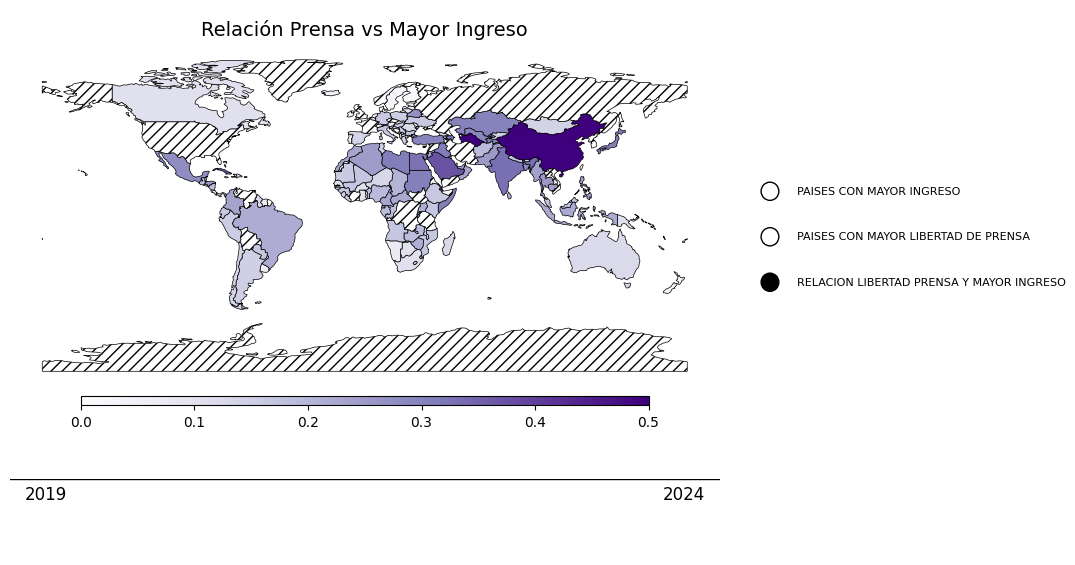

In [84]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

world = gpd.read_file("ne_data/ne_110m_admin_0_countries.shp")
df_press = pd.read_csv("indice_combinado.csv")

press = df_press[['2020_country_code', 'indice_combinado']].rename(columns={
    '2020_country_code': 'ISO_A3',
    'indice_combinado': 'promedio'
})

press['promedio'] = press['promedio'].replace(0, np.nan)

world_press = world.merge(press, on='ISO_A3', how='left')

fig = plt.figure(figsize=(11, 6))
grid_color = '#E6E6E6'
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(2, 2, height_ratios=[6, 1], width_ratios=[4, 1])

ax_map = fig.add_subplot(gs[0, 0])
world_press.plot(
    column='promedio',
    cmap='Purples',
    linewidth=0.5,
    ax=ax_map,
    edgecolor='black',
    legend=True,
    vmin=0,
    vmax=0.5,
    legend_kwds={
        'orientation': "horizontal",
        'shrink': 0.8,  # 👈 achica la barra
        'aspect': 60,   # 👈 más alargada y baja
        'pad': 0.02     # 👈 separa un poco del mapa
    },
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sin datos"
    }
)


ax_map.set_title('Relación Prensa vs Mayor Ingreso', fontsize=14)
ax_map.axis('off')

ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['2', '4', '6', '8', '10']
# Add the missing label for the first tick
labels = ['0'] + labels  # Now we have 6 labels for 6 ticks
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)

ax_timeline = fig.add_subplot(gs[1, 0])
ax_timeline.axhline(y=1, color='black', linestyle='-', linewidth=1)
ax_timeline.text(0.05, 0.8, '2019', fontsize=12, ha='center', va='center')
ax_timeline.text(0.95, 0.8, '2024', fontsize=12, ha='center', va='center')
ax_timeline.set_xlim(0, 1)
ax_timeline.set_ylim(0, 1)
ax_timeline.axis('off')

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')

# Create custom legend with circles
legend_y_positions = [0.6, 0.5, 0.4]
legend_labels = ['PAISES CON MAYOR INGRESO', 'PAISES CON MAYOR LIBERTAD DE PRENSA', 
                'RELACION LIBERTAD PRENSA Y MAYOR INGRESO']

# Add circles for the legend
oval_colors = ['white', 'white', 'black']
for i, (y, label, color) in enumerate(zip(legend_y_positions, legend_labels, oval_colors)):
    # Usar Ellipse con width=0.1 y height=0.04 para crear óvalos más alargados
    oval = Ellipse((0.2, y), width=0.1, height=0.04, facecolor=color, edgecolor='black')
    ax_legend.add_patch(oval)
    # Ajustar la posición del texto para que esté bien alineado con los óvalos
    ax_legend.text(0.35, y, label, va='center', fontsize=8)

plt.tight_layout()
plt.show()